# EDA — Batch1 기준 특성 선정

특성·모델 선정의 근거는 **Batch1 46개 셀**에서만 구한다. 모든 상관계수·회귀·피크·knee 분석은 Batch1만 사용한다.

Batch2에는 단수명 셀이 많다는 분포 관찰만 남긴다. 수명이 확인된 39개 중 500사이클 미만은 28개이며, Batch2의 운전조건·상관계수·예측 오차는 특성 선정에 사용하지 않는다. Batch3도 선정 분석에서 제외한다.

이 단계는 분포·가설·상관관계와 중복 제거 근거를 정리한다. 파생변수의 생성·선정과 최종 입력표 저장은 Feature Engineering에서 수행한다.

In [1]:
# 01에서 추출한 Batch1 셀 단위 CSV를 불러옵니다. 현재 EDA의 입력은 이 46개 셀입니다.
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT / "data/processed/batch1_cells.csv"

df = pd.read_csv(DATA_PATH)

# 값과 컬럼 구성을 먼저 보고, 행 수·자료형·결측치·중복을 확인해 분석 가능한 상태인지 점검합니다.
print("===== HEAD =====")
display(df.head())

print("\n===== SHAPE =====")
print(df.shape)

print("\n===== INFO =====")
df.info()

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== DUPLICATED ROWS =====")
print(df.duplicated().sum())

===== HEAD =====


,cell_id,channel,policy,cycle_life
0,1,47,3.6C(80%)-3.6C,1190
1,2,48,3.6C(80%)-3.6C,1179
2,3,49,3.6C(80%)-3.6C,1177
3,4,50,4C(80%)-4C,1226
4,5,51,4C(80%)-4C,1227



===== SHAPE =====
(46, 4)

===== INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   cell_id     46 non-null     int64
 1   channel     46 non-null     int64
 2   policy      46 non-null     str  
 3   cycle_life  46 non-null     int64
dtypes: int64(3), str(1)
memory usage: 1.6 KB

===== MISSING VALUES =====
cell_id       0
channel       0
policy        0
cycle_life    0
dtype: int64

===== DUPLICATED ROWS =====
0


## 기본 분포 분석

수명 분포와 정책별 표본 수·수명 차이를 살펴봅니다. 정책당 셀 수가 적으므로 개별 관측값도 함께 확인합니다.

In [2]:
# cycle_life 등의 범위를 파악하고 정책별 표본 수를 확인해 이후 비교의 해석 범위를 정합니다.
print("===== DESCRIPTIVE STATISTICS =====")
display(df.describe())

# 정책별 셀 수가 적으면 뒤의 평균·중앙값을 강한 결론으로 해석하기 어렵습니다.
print("\n===== POLICY COUNTS =====")
policy_counts = df["policy"].value_counts()
display(policy_counts)

===== DESCRIPTIVE STATISTICS =====


,cell_id,channel,cycle_life
count,46.000000,46.000000,46.000000
mean,23.500000,69.500000,844.717391
std,13.422618,13.422618,184.629198
min,1.000000,47.000000,534.000000
25%,12.250000,58.250000,703.250000
50%,23.500000,69.500000,858.500000
75%,34.750000,80.750000,914.250000
max,46.000000,92.000000,1227.000000



===== POLICY COUNTS =====


policy
3.6C(80%)-3.6C    3
4C(80%)-4C        2
4.8C(80%)-4.8C    2
5.4C(40%)-3.6C    2
5.4C(50%)-3C      2
5.4C(50%)-3.6C    2
5.4C(60%)-3C      2
5.4C(60%)-3.6C    2
5.4C(70%)-3C      2
5.4C(80%)-5.4C    2
6C(30%)-3.6C      2
6C(40%)-3C        2
6C(40%)-3.6C      2
6C(50%)-3C        2
6C(50%)-3.6C      2
6C(60%)-3C        2
7C(30%)-3.6C      2
7C(40%)-3C        2
7C(40%)-3.6C      2
8C(15%)-3.6C      2
8C(25%)-3.6C      2
8C(35%)-3.6C      2
4.4C(80%)-4.4C    1
Name: count, dtype: int64

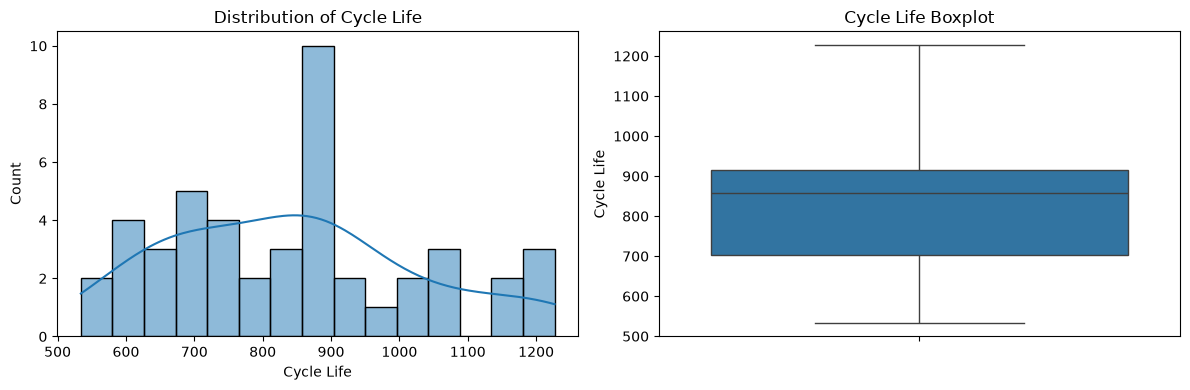

In [3]:
# 전체 수명 분포의 집중 구간, 비대칭성, 극단값 후보를 두 그림으로 살펴봅니다.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 히스토그램은 빈도와 분포 모양을, 박스플롯은 사분위 범위와 이상치 후보를 보여줍니다.
# 히스토그램
sns.histplot(
    data=df,
    x="cycle_life",
    bins=15,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribution of Cycle Life")
axes[0].set_xlabel("Cycle Life")
axes[0].set_ylabel("Count")

# 박스플롯
sns.boxplot(
    data=df,
    y="cycle_life",
    ax=axes[1]
)
axes[1].set_title("Cycle Life Boxplot")
axes[1].set_ylabel("Cycle Life")

plt.tight_layout()
plt.show()

,count,mean,median,min,max
policy,,,,,
4C(80%)-4C,2,1226.5,1226.5,1226,1227
3.6C(80%)-3.6C,3,1182.0,1179.0,1177,1190
4.4C(80%)-4.4C,1,1074.0,1074.0,1074,1074
8C(15%)-3.6C,2,1008.5,1008.5,966,1051
5.4C(40%)-3.6C,2,966.5,966.5,879,1054
6C(30%)-3.6C,2,952.5,952.5,891,1014
6C(40%)-3C,2,935.5,935.5,854,1017
5.4C(50%)-3.6C,2,899.5,899.5,897,902
6C(50%)-3C,2,888.5,888.5,860,917


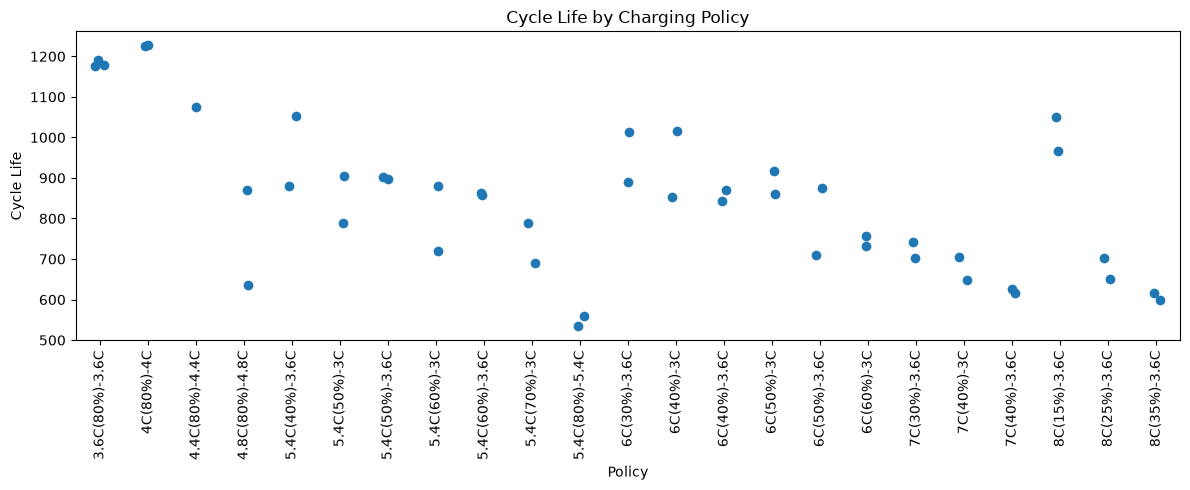

In [4]:
# 정책별 수명 요약과 개별 셀의 산포를 함께 보며 정책 간 차이와 내부 편차를 확인합니다.
policy_stats = (
    df.groupby("policy")["cycle_life"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(policy_stats)

# 표본 수가 적으므로 요약 통계만 보지 않고 strip plot에 각 관측값을 표시합니다.
plt.figure(figsize=(12, 5))

sns.stripplot(
    data=df,
    x="policy",
    y="cycle_life",
    jitter=True,
    size=7
)

plt.xticks(rotation=90)
plt.title("Cycle Life by Charging Policy")
plt.xlabel("Policy")
plt.ylabel("Cycle Life")

plt.tight_layout()
plt.show()

## 충전 정책 분해

정책 문자열에서 First C-rate, Switch SOC, Second C-rate를 추출해 비교 가능한 숫자 변수로 만듭니다.

In [5]:
# 정책 문자열을 세 숫자 변수로 풀어 충전 조건과 수명의 관계를 살펴볼 준비를 합니다.
import re

def parse_policy(policy):
    # 예: 3.6C(80%)-3.6C → 최초 C-rate, 전환 SOC, 이후 C-rate.
    pattern = r"([\d.]+)C\((\d+)%\)-([\d.]+)C"
    match = re.match(pattern, policy)

    if match:
        return pd.Series({
            "first_c_rate": float(match.group(1)),
            "switch_soc": int(match.group(2)),
            "second_c_rate": float(match.group(3))
        })

    # 형식이 맞지 않는 정책은 결측값으로 두어 파싱 실패를 확인할 수 있게 합니다.
    return pd.Series({
        "first_c_rate": None,
        "switch_soc": None,
        "second_c_rate": None
    })

policy_features = df["policy"].apply(parse_policy)

df_policy = pd.concat(
    [df, policy_features],
    axis=1
)

df_policy.head()

,cell_id,channel,policy,cycle_life,first_c_rate,switch_soc,second_c_rate
0,1,47,3.6C(80%)-3.6C,1190,3.6,80.0,3.6
1,2,48,3.6C(80%)-3.6C,1179,3.6,80.0,3.6
2,3,49,3.6C(80%)-3.6C,1177,3.6,80.0,3.6
3,4,50,4C(80%)-4C,1226,4.0,80.0,4.0
4,5,51,4C(80%)-4C,1227,4.0,80.0,4.0


## 정책 변수와 cycle life 관계 분석

각 변수의 단독 관계를 본 뒤 First C-rate와 Switch SOC의 조합을 살펴봅니다. 이 단계의 패턴은 탐색적 관찰입니다.

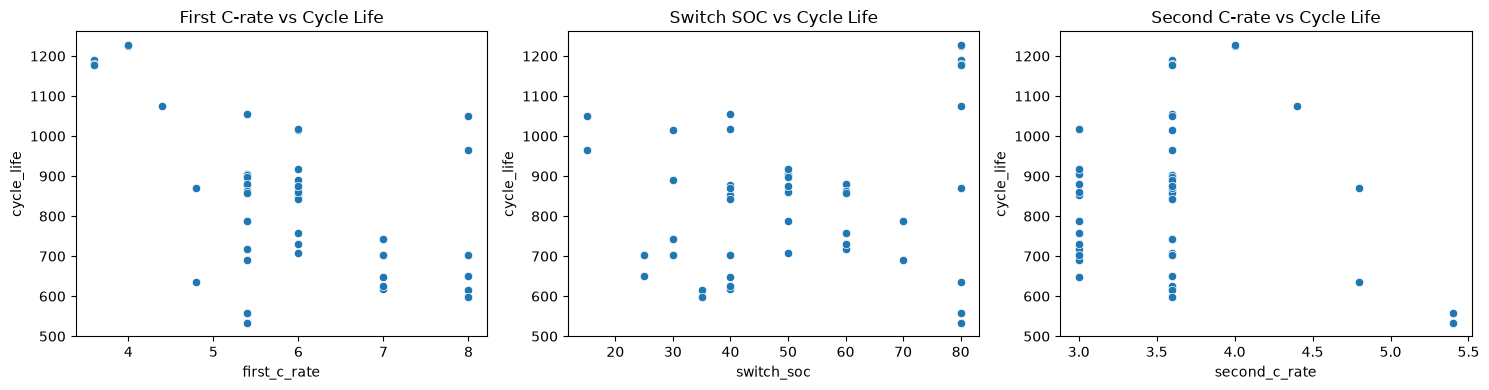

In [6]:
# 세 정책 변수 각각과 cycle_life의 관계를 수치와 산점도로 탐색합니다.
# 상관계수는 선형 경향의 참고값이며, 표본 수와 중복 조건을 함께 고려해야 합니다.
df_policy[
    ["first_c_rate", "switch_soc", "second_c_rate", "cycle_life"]
].corr()

# 각 산점도에서 방향성뿐 아니라 같은 조건에서의 수명 편차도 확인합니다.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(
    data=df_policy,
    x="first_c_rate",
    y="cycle_life",
    ax=axes[0]
)
axes[0].set_title("First C-rate vs Cycle Life")

sns.scatterplot(
    data=df_policy,
    x="switch_soc",
    y="cycle_life",
    ax=axes[1]
)
axes[1].set_title("Switch SOC vs Cycle Life")

sns.scatterplot(
    data=df_policy,
    x="second_c_rate",
    y="cycle_life",
    ax=axes[2]
)
axes[2].set_title("Second C-rate vs Cycle Life")

plt.tight_layout()
plt.show()

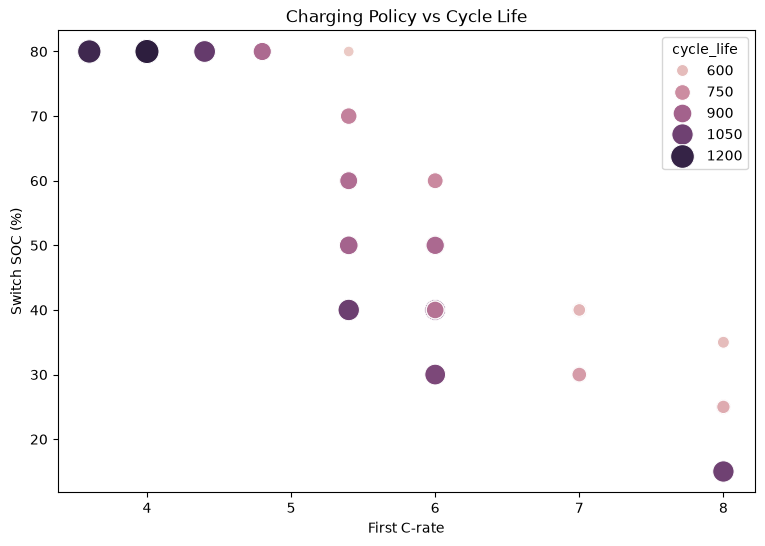

In [7]:
# First C-rate와 Switch SOC의 조합별 수명을 비교해 단일 변수에서 놓친 패턴을 찾습니다.
plt.figure(figsize=(9, 6))

# 점의 색과 크기로 cycle_life를 표시합니다. 같은 좌표의 셀은 겹쳐 보일 수 있습니다.
sns.scatterplot(
    data=df_policy,
    x="first_c_rate",
    y="switch_soc",
    size="cycle_life",
    hue="cycle_life",
    sizes=(50, 300)
)

plt.title("Charging Policy vs Cycle Life")
plt.xlabel("First C-rate")
plt.ylabel("Switch SOC (%)")
plt.show()

## 네 가설과 수명의 관계

수명 범위는 534~1227사이클, 중앙값은 858.5사이클이다. 단수명(<500)은 0개, 장수명(>1000)은 10개다. 수명과의 관계를 연속값으로 확인한다.

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress, spearmanr
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "processed"
BATCHES = ["batch1"]
KEYS = ["batch", "cell_id"]
sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:.3g}".format
np.random.seed(42)

all_cells = pd.concat([
    pd.read_csv(DATA / f"{batch}_cells.csv").assign(batch=batch) for batch in BATCHES
], ignore_index=True)
all_summary = pd.concat([
    pd.read_csv(DATA / f"{batch}_cycle_summary.csv").assign(batch=batch) for batch in BATCHES
], ignore_index=True)
assert not all_cells.duplicated(KEYS).any()
assert not all_summary.duplicated(KEYS + ["cycle"]).any()

all_cells["protocol"] = all_cells["policy"].str.extract(
    r"^(\d+(?:\.\d+)?C\(\d+(?:\.\d+)?%\)-\d+(?:\.\d+)?C)", expand=False
).fillna(all_cells["policy"])
known = all_cells.dropna(subset=["cycle_life"]).copy()
assert np.isfinite(known["cycle_life"]).all() and known["cycle_life"].gt(0).all()
known["short_life"] = known["cycle_life"] < 500
print(f"전체 {len(all_cells)}개 중 수명 확인 {len(known)}개, 수명 결측 {len(all_cells) - len(known)}개")

def association_table(frame, features):
    rows = []
    for group_name, group in [("batch1", frame)]:
        for feature in features:
            valid = group[[feature, "cycle_life"]].dropna()
            if len(valid) < 3 or valid.nunique().min() < 2:
                continue
            fit = linregress(valid[feature], valid["cycle_life"])
            rows.append({"group": group_name, "feature": feature, "n": len(valid),
                         "Pearson_r": fit.rvalue,
                         "Spearman_rho": spearmanr(valid[feature], valid["cycle_life"]).statistic,
                         "R2": fit.rvalue ** 2, "p_value": fit.pvalue})
    return pd.DataFrame(rows)

# 완전한 직선 관계에서 r와 R²가 1인지 확인한다.
check = association_table(pd.DataFrame({"batch": ["toy"] * 3, "x": [1, 2, 3],
                                      "cycle_life": [100, 200, 300]}), ["x"])
assert np.allclose(check[["Pearson_r", "R2"]], 1)

전체 46개 중 수명 확인 46개, 수명 결측 0개


### 1. 운전조건으로 단수명을 구분할 수 있는가? → 이번 선정 근거에서 제외

Batch1에는 단수명(<500사이클) 셀이 없어 단수명 여부를 충전 조건으로 분류하는 가설을 검증할 수 없다. 충전속도·전환 SOC와 연속적인 수명의 관계는 위 정책 분석에서 확인한다. Batch2 단수명 집중은 분포 관찰로만 남긴다.

### 2. Q 급변 구간의 크기·변화가 수명과 관련되는가? → 기각

2.7~3.4 V 구간의 cycle 10/100 곡선에서 피크 크기와 피크 전압 이동량을 계산한다.

,group,feature,n,Pearson_r,Spearman_rho,R2,p_value
0,batch1,peak_height_10,46,-0.24,-0.214,0.0574,0.109
1,batch1,peak_shift_mv,46,-0.226,-0.246,0.0513,0.13


Cycle 10 피크 전압: 중앙값 3.152 V, 범위 3.144~3.162 V


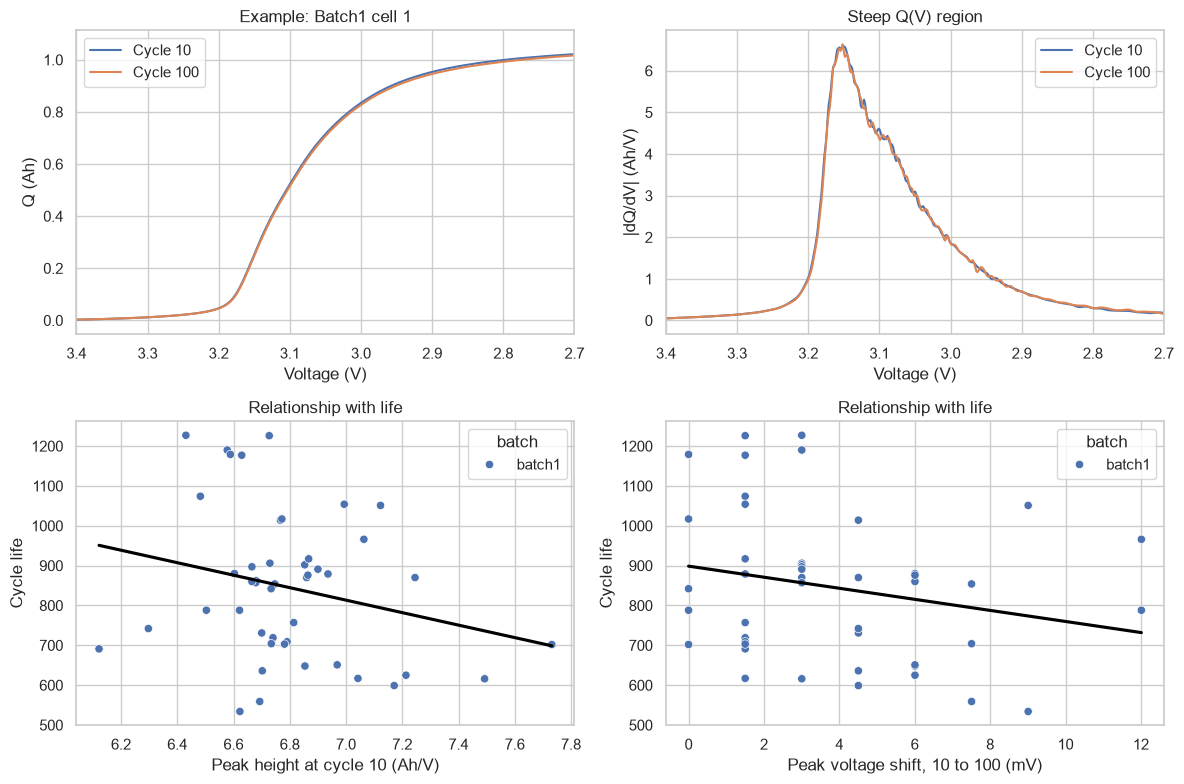

In [9]:
V_WINDOW = (2.7, 3.4)
voltage = pd.read_csv(DATA / "batch1_vdlin.csv")["Vdlin"].to_numpy()
inside = np.flatnonzero((voltage >= V_WINDOW[0]) & (voltage <= V_WINDOW[1]))
assert len(inside) > 2 and np.all(np.diff(voltage) < 0)
profile_rows, example_q = [], {}
for batch in BATCHES:
    v = pd.read_csv(DATA / f"{batch}_vdlin.csv")["Vdlin"].to_numpy()
    assert np.allclose(v, voltage, rtol=0, atol=1e-12)
    with np.load(DATA / f"{batch}_cycle_profiles.npz", allow_pickle=False) as archive:
        for cell_id in all_cells.loc[all_cells["batch"].eq(batch), "cell_id"]:
            cycles = archive[f"cell_{cell_id}_cycle"]
            indices = [np.flatnonzero(cycles == cycle) for cycle in [10, 100]]
            assert all(len(index) == 1 for index in indices), f"{batch}/{cell_id}: cycle 10 또는 100 없음"
            q = archive[f"cell_{cell_id}_qdlin"]
            assert q.shape == (len(cycles), len(v))
            q10, q100 = q[indices[0][0]], q[indices[1][0]]
            assert np.isfinite([q10, q100]).all()
            slopes = [np.abs(np.gradient(curve, v)) for curve in [q10, q100]]
            # ponytail: 최대 피크만 비교한다. 피크가 서로 바뀌는 셀은 별도 피크 추적으로 확인한다.
            peaks = [inside[np.argmax(slope[inside])] for slope in slopes]
            variance = np.var(q100 - q10)
            profile_rows.append({"batch": batch, "cell_id": cell_id,
                                 "peak_voltage_10": v[peaks[0]],
                                 "peak_height_10": slopes[0][peaks[0]],
                                 "peak_shift_mv": abs(v[peaks[1]] - v[peaks[0]]) * 1000,
                                 "log10_dqv_var": np.log10(variance) if variance > 0 else np.nan})
            if batch == "batch1" and cell_id == 1:
                example_q = {10: q10.copy(), 100: q100.copy()}
            del q

features = known.merge(pd.DataFrame(profile_rows), on=KEYS, validate="one_to_one")
assert len(features) == len(known)
peak_stats = association_table(features, ["peak_height_10", "peak_shift_mv"])
display(peak_stats)
print(f"Cycle 10 피크 전압: 중앙값 {features['peak_voltage_10'].median():.3f} V, "
      f"범위 {features['peak_voltage_10'].min():.3f}~{features['peak_voltage_10'].max():.3f} V")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for cycle, curve in example_q.items():
    axes[0, 0].plot(voltage, curve, label=f"Cycle {cycle}")
    axes[0, 1].plot(voltage, np.abs(np.gradient(curve, voltage)), label=f"Cycle {cycle}")
axes[0, 0].set(title="Example: Batch1 cell 1", xlabel="Voltage (V)", ylabel="Q (Ah)", xlim=(3.4, 2.7))
axes[0, 1].set(title="Steep Q(V) region", xlabel="Voltage (V)", ylabel="|dQ/dV| (Ah/V)", xlim=(3.4, 2.7))
for ax in axes[0]:
    ax.legend()
for ax, feature, label in zip(axes[1], ["peak_height_10", "peak_shift_mv"],
                              ["Peak height at cycle 10 (Ah/V)", "Peak voltage shift, 10 to 100 (mV)"]):
    sns.scatterplot(data=features, x=feature, y="cycle_life", hue="batch", ax=ax)
    sns.regplot(data=features, x=feature, y="cycle_life", scatter=False, ci=None, color="black", ax=ax)
    ax.set(title="Relationship with life", xlabel=label, ylabel="Cycle life")
plt.tight_layout()
plt.show()

Batch1의 피크 크기는 Pearson r=-0.240, p=0.109, 피크 전압 이동량은 r=-0.226, p=0.130다. 두 지표의 직선 관계 R²는 각각 0.057, 0.051으로 약하다. 현재 정의한 피크 지표는 수명 예측 후보에서 제외한다.

### 3. 이른 knee가 짧은 수명과 관련되는가? → 초기 입력에서 제외

열화곡선의 knee는 후기 진단으로 확인하되 초기 100사이클 입력으로 사용하지 않는다.

,n,detected_knees
batch,,
batch1,46,45


,group,feature,n,Pearson_r,Spearman_rho,R2,p_value
0,batch1,knee_cycle,45,0.827,0.866,0.684,2.57e-12


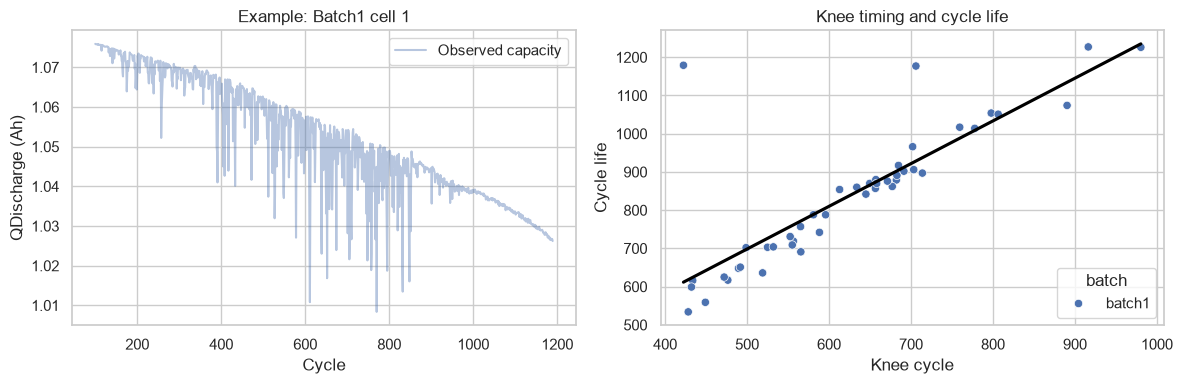

In [10]:
KNEE_START_CYCLE = 100
KNEE_WINDOWS = [11, 21, 41]
MIN_SEGMENT_POINTS = 50
MIN_SSE_GAIN = 0.10

def fit_knee(x, y):
    """이어 붙인 두 직선으로 꺾임을 찾습니다. 직선이면 꺾임이 없다고 봅니다."""
    if len(x) < 2 * MIN_SEGMENT_POINTS + 1:
        return None
    base = np.column_stack([np.ones(len(x)), x])
    base_fit = base @ np.linalg.lstsq(base, y, rcond=None)[0]
    base_sse = np.sum((y - base_fit) ** 2)
    if base_sse <= 1e-12:
        return None
    best = None
    for knee in np.linspace(x[MIN_SEGMENT_POINTS], x[-MIN_SEGMENT_POINTS - 1], 80):
        design = np.column_stack([base, np.maximum(0, x - knee)])
        coef = np.linalg.lstsq(design, y, rcond=None)[0]
        fit = design @ coef
        sse = np.sum((y - fit) ** 2)
        if best is None or sse < best["sse"]:
            best = {"knee_cycle": knee, "sse": sse, "fit": fit,
                    "slope_before": coef[1], "slope_after": coef[1] + coef[2]}
    best["sse_gain"] = 1 - best["sse"] / base_sse
    best["candidate"] = (best["sse_gain"] >= MIN_SSE_GAIN and
                         best["slope_after"] < min(best["slope_before"], 0))
    return best

# 꺾임 위치를 아는 예시와 그냥 직선인 예시로 코드가 맞게 동작하는지 확인합니다.
toy_x = np.arange(1, 301, dtype=float)
toy_y = 1.1 - 0.00005 * toy_x - 0.0005 * np.maximum(0, toy_x - 180)
toy_result = fit_knee(toy_x, toy_y)
assert toy_result["candidate"] and abs(toy_result["knee_cycle"] - 180) < 5
assert fit_knee(toy_x, 1.1 - 0.0001 * toy_x) is None

knee_rows = []
for row in known.itertuples(index=False):
    track = all_summary.loc[
        all_summary["batch"].eq(row.batch) & all_summary["cell_id"].eq(row.cell_id)
        & all_summary["cycle"].between(KNEE_START_CYCLE, row.cycle_life)
    ].sort_values("cycle").dropna(subset=["QDischarge"])
    x = track["cycle"].to_numpy(dtype=float)
    q = track["QDischarge"].to_numpy()
    found = {}
    for window in KNEE_WINDOWS:
        smooth = pd.Series(q).rolling(window, center=True, min_periods=1).median().to_numpy()
        fit = fit_knee(x, smooth)
        if fit is not None and fit["candidate"]:
            found[window] = fit
    stable = len(found) == len(KNEE_WINDOWS) and np.ptp([f["knee_cycle"] for f in found.values()]) <= 20
    knee_rows.append({"batch": row.batch, "cell_id": row.cell_id,
                      "knee_cycle": found[21]["knee_cycle"] if stable else np.nan})

knees = known.merge(pd.DataFrame(knee_rows), on=KEYS, validate="one_to_one")
display(knees.groupby("batch").agg(n=("cell_id", "size"), detected_knees=("knee_cycle", "count")))
stable_knees = knees.dropna(subset=["knee_cycle"])
knee_stats = association_table(stable_knees, ["knee_cycle"])
display(knee_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
example_life = known.loc[known["batch"].eq("batch1") & known["cell_id"].eq(1), "cycle_life"].iloc[0]
example = all_summary.loc[
    all_summary["batch"].eq("batch1") & all_summary["cell_id"].eq(1)
    & all_summary["cycle"].between(KNEE_START_CYCLE, example_life)
].sort_values("cycle")
x = example["cycle"].to_numpy(dtype=float)
q = example["QDischarge"].to_numpy()
smooth = pd.Series(q).rolling(21, center=True, min_periods=1).median().to_numpy()
fit = fit_knee(x, smooth)
axes[0].plot(x, q, alpha=0.4, label="Observed capacity")
if fit is not None and fit["candidate"]:
    axes[0].plot(x, fit["fit"], color="black", label="Two-line fit")
    axes[0].axvline(fit["knee_cycle"], linestyle="--", color="red", label=f"Knee: {fit['knee_cycle']:.0f}")
axes[0].set(title="Example: Batch1 cell 1", xlabel="Cycle", ylabel="QDischarge (Ah)")
axes[0].legend()
sns.scatterplot(data=stable_knees, x="knee_cycle", y="cycle_life", hue="batch", ax=axes[1])
sns.regplot(data=stable_knees, x="knee_cycle", y="cycle_life", scatter=False, ci=None, color="black", ax=axes[1])
axes[1].set(title="Knee timing and cycle life", xlabel="Knee cycle", ylabel="Cycle life")
plt.tight_layout()
plt.show()

Batch1에서 안정적으로 탐지된 knee는 45/46개이며, 수명과 Pearson r=0.827, Spearman ρ=0.866이다. 수명과의 관련성은 있지만 꺾임 이후 기록을 사용해 찾은 값이므로 초기 예측 입력에서는 제외한다.

### 4. 초기 ΔQ(V) 로그 분산이 수명과 관련되는가? → 유지

cycle 100과 10의 보간 Q(V) 차이를 동일한 전압축에서 계산한다. 모든 셀의 값은 초기 100사이클 이내에서 얻는다.

,group,feature,n,Pearson_r,Spearman_rho,R2,p_value
0,batch1,log10_dqv_var,46,-0.886,-0.871,0.785,2.7e-16


초기 ΔQ(V) 분산 범위: 9.66e-06~4.46e-04 Ah²


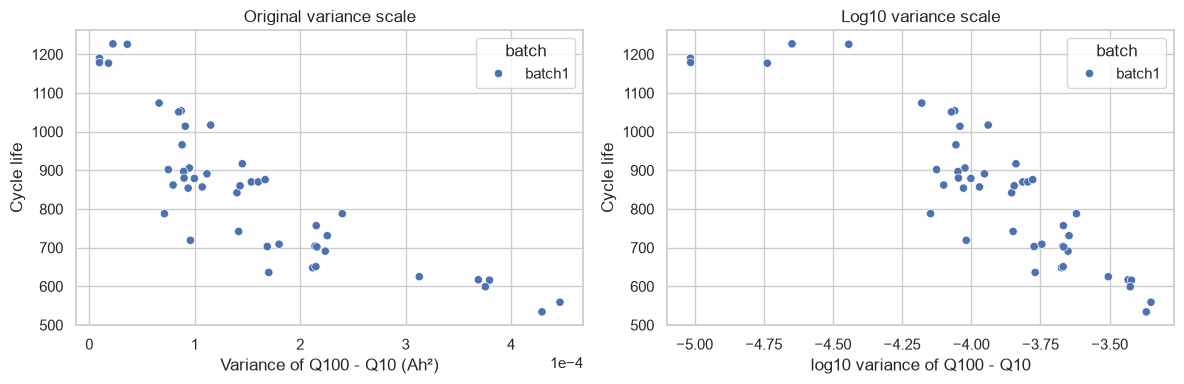

In [11]:
dqv_stats = association_table(features, ["log10_dqv_var"])
display(dqv_stats)


# 같은 셀을 원래 분산 축과 log10 축에서 비교한다.
features["dqv_var"] = np.power(10.0, features["log10_dqv_var"])
print(f"초기 ΔQ(V) 분산 범위: {features['dqv_var'].min():.2e}~{features['dqv_var'].max():.2e} Ah²")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feature, title, xlabel in zip(
    axes, ["dqv_var", "log10_dqv_var"], ["Original variance scale", "Log10 variance scale"],
    ["Variance of Q100 - Q10 (Ah²)", "log10 variance of Q100 - Q10"]
):
    sns.scatterplot(data=features, x=feature, y="cycle_life", hue="batch", ax=ax)
    ax.set(title=title, xlabel=xlabel, ylabel="Cycle life")
axes[0].ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
plt.tight_layout()
plt.show()



로그를 그린 이유는 Batch1의 분산이 9.66e-06~4.46e-04 Ah²로 약 46.2배 차이 나기 때문이다. 로그 축은 작은 값이 몰리는 현상을 줄이고 셀 간 변화량을 읽기 쉽게 한다.

Batch1에서 수명과 Pearson r=-0.886, Spearman ρ=-0.871, 단순 회귀 R²=0.785이다. 초기 곡선 변화의 분산이 큰 셀일수록 수명이 짧은 경향이 뚜렷해 로그 지표를 유지한다. target은 로그 변환하지 않은 cycle_life다.

분산은 총용량 감소량만이 아니라 전압별 변화의 불균일성을 담는다. LFP/흑연 셀에서는 초기 활성물질 손실 등이 총용량 감소 전에 전압 곡선에 나타날 수 있어 초기 열화 신호로 해석한다. [Severson et al. (2019)](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)

간단한 한계: 상관계수와 R²는 이 데이터의 관계를 요약하며 원인이나 새 셀의 예측 성능을 입증하지 않는다.

## 정책·초기 측정값·로그 지표의 상관관계

정책 변수와 초기 1~100사이클 평균 측정값, 로그 지표를 비교한다. 수명 전체의 측정값 평균과 기록 길이는 입력 후보로 사용하지 않는다.

batch
batch1    46
Name: n_cells, dtype: int64

,Pearson,Spearman
group,batch1,batch1
feature,,
first_c_rate,-0.58,-0.483
switch_soc,0.235,0.185
second_c_rate,-0.096,0.047
mean_QCharge,-0.059,0.187
mean_QDischarge,0.193,0.185
mean_IR,0.177,0.136
mean_Tavg,-0.482,-0.371
mean_Tmax,-0.404,-0.323


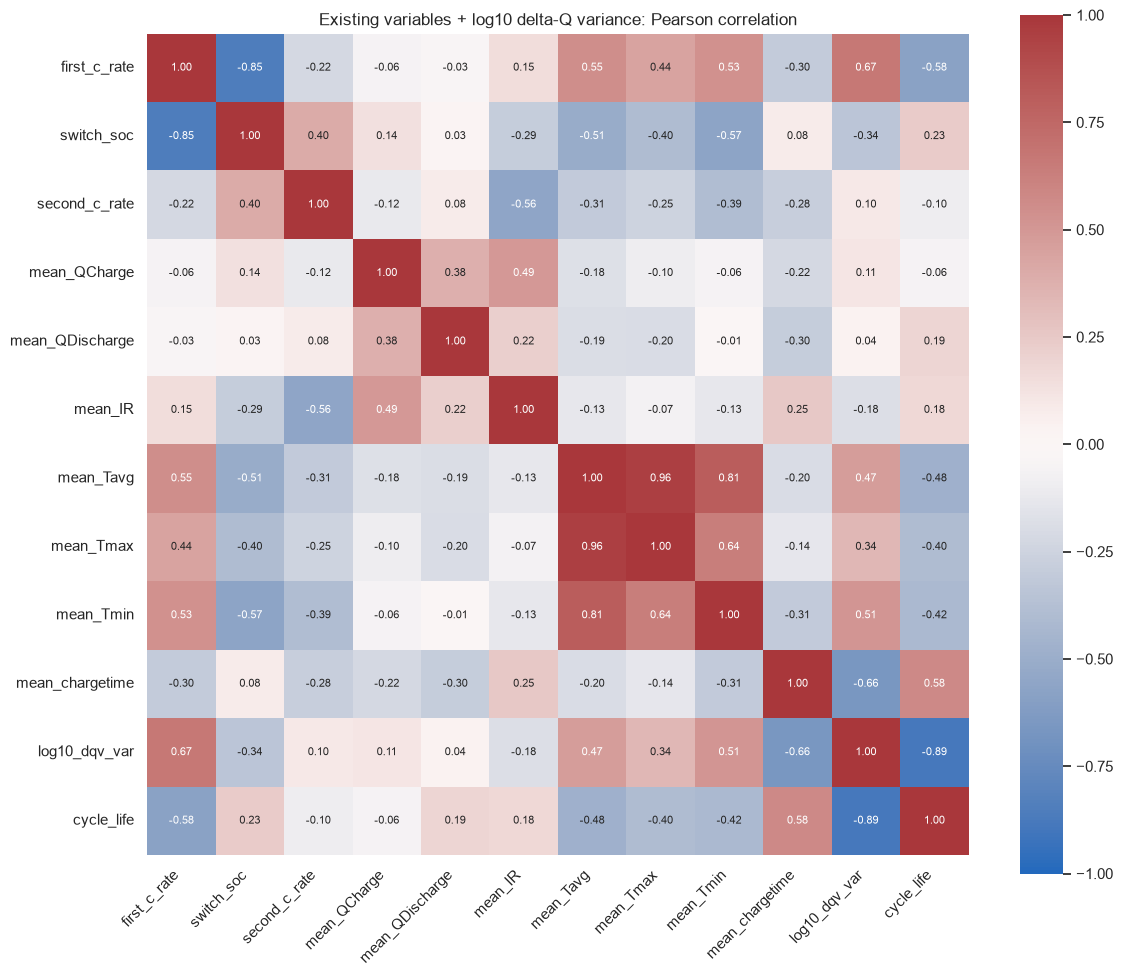

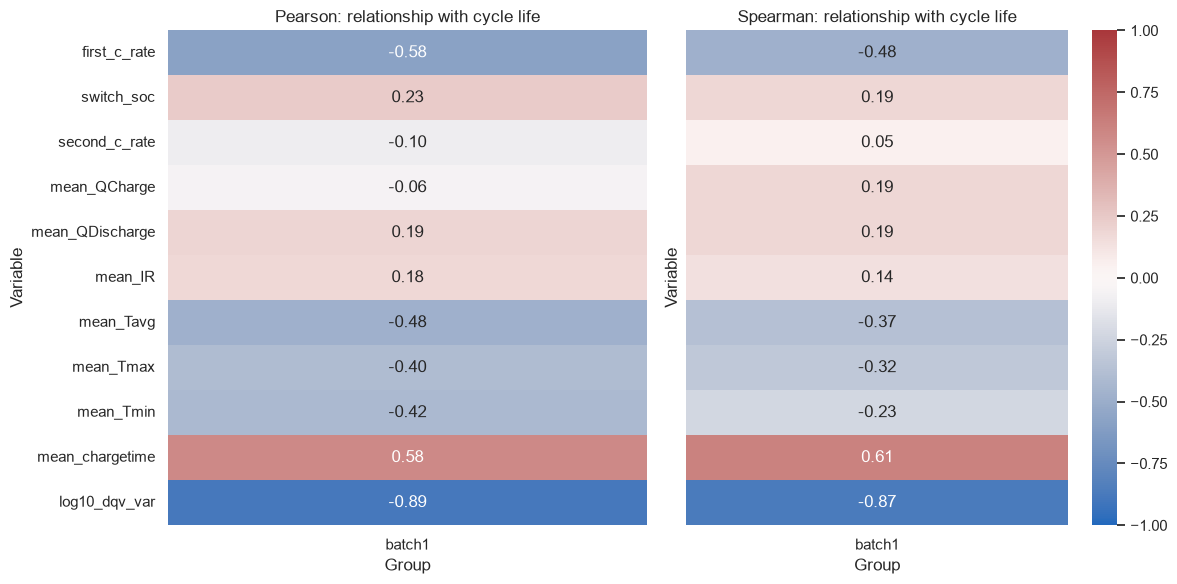

변수끼리 |Pearson r| >= 0.8인 쌍


,variable_1,variable_2,Pearson_r
0,mean_Tavg,mean_Tmax,0.956
1,first_c_rate,switch_soc,-0.854
2,mean_Tavg,mean_Tmin,0.811


In [12]:
# 앞에서 읽은 데이터, 충전 정책 파서, 로그 지표를 재사용한다.
measurements = ["QCharge", "QDischarge", "IR", "Tavg", "Tmax", "Tmin", "chargetime"]
placeholder = all_summary["cycle"].eq(1) & all_summary[measurements].eq(0).all(axis=1)
early = all_summary.loc[all_summary["cycle"].between(1, 100) & ~placeholder]
early_means = early.groupby(KEYS)[measurements].mean().add_prefix("mean_").reset_index()
policy_values = all_cells["policy"].apply(parse_policy)
correlation_data = pd.concat([all_cells[KEYS + ["cycle_life"]], policy_values], axis=1)
correlation_data = correlation_data.merge(early_means, on=KEYS, validate="one_to_one")
correlation_data = correlation_data.merge(
    features[KEYS + ["log10_dqv_var"]], on=KEYS, how="left", validate="one_to_one"
).dropna(subset=["cycle_life"])
correlation_features = ["first_c_rate", "switch_soc", "second_c_rate",
                        *[f"mean_{name}" for name in measurements], "log10_dqv_var"]
assert not correlation_data.duplicated(KEYS).any()
assert len(correlation_data) == len(known)
assert np.isfinite(correlation_data[correlation_features + ["cycle_life"]].to_numpy()).all()
display(correlation_data.groupby("batch").size().rename("n_cells"))

correlation_stats = association_table(correlation_data, correlation_features)
group_order = ["batch1"]
pearson_life = correlation_stats.pivot(index="feature", columns="group", values="Pearson_r").reindex(
    index=correlation_features, columns=group_order
)
spearman_life = correlation_stats.pivot(index="feature", columns="group", values="Spearman_rho").reindex(
    index=correlation_features, columns=group_order
)
# 로그 지표가 같은 셀에 연결됐는지 앞의 분석 결과와 대조한다.
assert np.isclose(pearson_life.loc["log10_dqv_var", "batch1"],
                  dqv_stats.loc[dqv_stats["group"].eq("batch1"), "Pearson_r"].iloc[0])
display(pd.concat({"Pearson": pearson_life, "Spearman": spearman_life}, axis=1).round(3))

correlation_matrix = correlation_data[correlation_features + ["cycle_life"]].corr(method="pearson")
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, square=True, annot_kws={"fontsize": 8}, ax=ax)
ax.set(title="Existing variables + log10 delta-Q variance: Pearson correlation")
ax.tick_params(axis="x", labelrotation=45)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for ax, matrix, title in zip(axes, [pearson_life, spearman_life], ["Pearson", "Spearman"]):
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1,
                cbar=ax is axes[1], ax=ax)
    ax.set(title=f"{title}: relationship with cycle life", xlabel="Group", ylabel="Variable")
plt.tight_layout()
plt.show()

# 변수끼리 가장 강하게 연결된 쌍을 확인한다.
feature_matrix = correlation_matrix.loc[correlation_features, correlation_features]
upper = np.triu(np.ones(feature_matrix.shape, dtype=bool), k=1)
pair_rows = [(feature_matrix.index[i], feature_matrix.columns[j], feature_matrix.iloc[i, j])
             for i, j in zip(*np.where(upper))]
strong_pairs = pd.DataFrame(pair_rows, columns=["variable_1", "variable_2", "Pearson_r"])
strong_pairs = strong_pairs.loc[strong_pairs["Pearson_r"].abs().ge(0.8)].sort_values(
    "Pearson_r", key=lambda values: values.abs(), ascending=False
)
print("변수끼리 |Pearson r| >= 0.8인 쌍")
display(strong_pairs.round(3).reset_index(drop=True))

### 특성과 수명의 관계

- 로그 지표는 r=−0.886으로 정책·초기 측정 후보 중 수명과 가장 강하게 연결된다.
- 1단계 충전속도 r=−0.580, 충전시간 r=+0.577은 유효한 후보다.
- 평균 온도 r=−0.482, 최소 온도 r=−0.418, 최대 온도 r=−0.404다. 수명과의 상관 절댓값이 가장 큰 Tavg를 온도 대표로 선택한다.
- 전환 SOC r=+0.235, 2단계 속도 r=−0.096, 충전용량 r=−0.059, 방전용량 r=+0.193, 저항 r=+0.177은 단독 관계가 약하다. 단독 상관이 약하다는 이유만으로 도메인 조합의 재료에서 제거하지 않는다.

도메인 지표의 생성·선정은 Feature Engineering에서 수행한다.

## Feature Engineering으로 전달할 결론

독립변수끼리 Pearson 상관 절댓값이 0.8 이상이면 중복 후보로 보고, 수명과의 관계와 변수의 역할을 고려해 대표를 남긴다.

| 항목 | Batch1 근거 | 적용한 선택 |
|---|---|---|
| 온도 대표 | Tavg–Tmax r=0.956, Tavg–Tmin r=0.811. 수명과의 상관 절댓값은 Tavg 0.482, Tmin 0.418, Tmax 0.404 | **Tavg 유지**, Tmin·Tmax는 직접 입력 후보에서 제외 |
| 정책 대표 | 1단계 속도–전환 SOC r=−0.854. 수명과의 상관 절댓값은 1단계 속도 0.580, 전환 SOC 0.235 | **1단계 속도 유지**, 전환 SOC는 직접 입력 후보에서 제외하되 파생변수 생성 재료로 보존 |

**기본 직접 입력 후보 8개:** `first_c_rate`, `second_c_rate`, `mean_QCharge`, `mean_QDischarge`, `mean_IR`, `mean_Tavg`, `mean_chargetime`, `log10_dqv_var`.

전환 SOC는 최종 직접 입력과 구분해 충전 부담 계산에 사용한다. 도메인 조합은 초기 100사이클 관측과 정책만으로 계산하며, 후보의 수명 관계·중복 판단도 Batch1만으로 수행한다.